In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import ast
from scipy import stats
import librosa
import warnings

In [75]:
print(os.getcwd())
paths = {}
for root, dirs, files in os.walk(os.path.join(os.getcwd(), "fma_small")):
    if root.endswith("fma_small"):
        continue
    for file in files:
        full_path = os.path.join(root, file)
        track_id = int(file.split(".")[0])
        paths[track_id] = full_path

/home/jakub-karczewski/Dokumenty/data_exploration_project


In [76]:
paths
len(list(paths.keys()))

8000

In [77]:
df_tracks = pd.read_csv(os.path.join(os.getcwd(), "fma_metadata", "tracks.csv"), index_col=0, header=[0, 1])
df_tracks.head()

album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   

                                                                          \
         favorites id                                information listens   
track_id                                                                   
2                4  1                                    <p></p>    6073   
3                4  1                                    <p></p>    6073   
5                4  1                                    <p></p>    6073   
10               4  6                                        NaN   47632   
20               2  4  <p> "spiritual songs" from Nicky Cook</p>    2710   

                        ...       track                         \
         producer tags  ... information interest language_code   
track_id                ...                                      
2             NaN   []  ...         NaN     4656            en   
3             NaN   []  ...         NaN     1470            en   
5             NaN   []  ...         NaN     1933            en   
10            NaN   []  ...         NaN    54881            en   
20            NaN   []  ...         NaN      978            en   

                                                                              \
                                                    license listens lyricist   
track_id                                                                       
2         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1293      NaN   
3         Attribution-NonCommercial-ShareAlike 3.0 Inter...     514      NaN   
5         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1151      NaN   
10        Attribution-NonCommercial-NoDerivatives (aka M...   50135      NaN   
20        Attribution-NonCommercial-NoDerivatives (aka M...     361      NaN   

                                                 
         number publisher tags            title  
track_id                                         
2             3       NaN   []             Food  
3             4       NaN   []     Electric Ave  
5             6       NaN   []       This World  
10            1       NaN   []          Freeway  
20            3       NaN   []  Spiritual Level  

[5 rows x 52 columns]

In [78]:
keep_tracks = df_tracks[df_tracks[('set', 'subset')] == 'small']
df_tracks = keep_tracks[[('track', 'genre_top'), ('set', 'split')]].reset_index()
df_tracks.columns = ['track_id', 'genre_top', 'split']

In [79]:
df_tracks.value_counts('split')

split
training      6400
validation     800
test           800
Name: count, dtype: int64

In [80]:
df_tracks["genre_top"].value_counts()

genre_top
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64

In [82]:
def columns():
    feature_sizes = dict(
        chroma_stft=12,
        mfcc=20, rms=1, zcr=1,
        spectral_centroid=1
    )
    moments = ('mean', 'std')

    tuples = [
        (feature, moment, f"{i+1:02d}")
        for feature, size in feature_sizes.items()
        for moment in moments
        for i in range(size)
    ]

    return pd.MultiIndex.from_tuples(tuples, names=('feature', 'statistics', 'number')).sort_values()

In [83]:
import librosa
import numpy as np
import pandas as pd
import torch

from panns_inference import AudioTagging

device = 'cuda' if torch.cuda.is_available() else 'cpu'

audio_tagging = AudioTagging(
    checkpoint_path=None,
    device=device
)

EMBEDDING_SIZE = 2048


def compute_panns_features(tid):
    filepath = paths[tid]

    try:
        audio, sr = librosa.load(
            filepath,
            sr=32000,
            mono=True,
            dtype=np.float32
        )

        audio = audio[None, :]

        with torch.no_grad():
            clipwise_output, embedding = audio_tagging.inference(audio)

        if torch.is_tensor(embedding):
            embedding = embedding.cpu().numpy()

        embedding = embedding.squeeze()

        return pd.Series(embedding, name=tid)

    except Exception as e:
        print(f"Error processing {tid}: {e}")

        return pd.Series(
            np.zeros(EMBEDDING_SIZE, dtype=np.float32),
            name=tid
        )

Checkpoint path: /home/jakub-karczewski/panns_data/Cnn14_mAP=0.431.pth
GPU number: 1


In [84]:
track_ids = list(paths.keys())

features = pd.DataFrame(
    index=track_ids,
    columns=columns(),
    dtype=np.float32
)

### To be used on Linux

In [85]:
results = []
valid_track_ids = []

log_step = 250
limit = 8000

for i, tid in enumerate(track_ids[:limit]):
    if i % log_step == 0:
        print(i, end=' ')

    res_i = compute_panns_features(tid)

    if np.all(res_i == 0):
        print(f"Track {tid} resulted in zero embedding.")
    else:
        results.append(res_i)
        valid_track_ids.append(tid)

df = pd.DataFrame(results)
df.insert(0, "track_id", valid_track_ids)

df.to_csv("panns_features.csv", index=False)

0 250 500 750 1000 1250 

[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


1500 1750 2000 

[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


2250 2500 2750 

...

Error processing 98567: 
Track 98567 resulted in zero embedding.
4500 4750 5000 5250 5500 5750 6000 6250 6500 6750 7000 Error processing 99134: 
Track 99134 resulted in zero embedding.


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


7250 7500 Error processing 133297: 
Track 133297 resulted in zero embedding.


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


7750 

In [86]:
print(df.shape)

(7994, 2049)


In [87]:
df = df.reset_index(drop=True)
df.head(10)

,track_id,0,1,2,3,4,5,6,7,8,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,120161,0.0,0.000000,0.0,0.0,0.0,0.065903,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.041369,0.000000,0.778215,0.0
1,120325,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.944425,0.000000,0.174031,0.0
2,120315,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.330279,0.059467,0.000798,0.0
3,120504,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.328960,0.069268,0.000000,0.0
4,120312,0.0,0.270404,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.789381,0.000000,0.486817,0.0
5,120462,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.829002,0.023686,0.291630,0.0
6,120324,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.135046,0.000528,0.000000,0.0
7,120296,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.581628,0.137893,0.000000,0.0
8,120778,0.0,0.000000,0.0,0.0,0.0,0.138926,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.162956,0.221825,0.000000,0.0
9,120333,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.064390,0.000000,0.000000,0.0


In [88]:
df = df.merge(df_tracks[['track_id', 'genre_top', 'split']], on='track_id', how='left')
col = df.pop('genre_top')
df.insert(1, 'genre', col)

In [89]:
df.head(10)

,track_id,genre,0,1,2,3,4,5,6,7,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,split
0,120161,Experimental,0.0,0.000000,0.0,0.0,0.0,0.065903,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.041369,0.000000,0.778215,0.0,training
1,120325,Instrumental,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.944425,0.000000,0.174031,0.0,training
2,120315,Instrumental,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.330279,0.059467,0.000798,0.0,training
3,120504,Instrumental,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.328960,0.069268,0.000000,0.0,training
4,120312,Instrumental,0.0,0.270404,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.789381,0.000000,0.486817,0.0,training
5,120462,Electronic,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.829002,0.023686,0.291630,0.0,training
6,120324,Instrumental,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.135046,0.000528,0.000000,0.0,training
7,120296,Instrumental,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.581628,0.137893,0.000000,0.0,training
8,120778,Instrumental,0.0,0.000000,0.0,0.0,0.0,0.138926,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.162956,0.221825,0.000000,0.0,training
9,120333,Instrumental,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.064390,0.000000,0.000000,0.0,training


In [90]:
df.isna().sum().sum()

np.int64(0)

In [91]:
feature_cols = df.columns[1:-2]
zero_rows = (df[feature_cols] == 0).all(axis=1)

zero_rows.sum()

np.int64(0)

In [92]:
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

train_mask = df['split'] == 'training'
test_mask = df['split'].isin(['test', 'validation'])

cols_to_drop = ['track_id', 'genre', 'split']

X_train = df.loc[train_mask].drop(columns=cols_to_drop)
y_train = df.loc[train_mask, 'genre']

X_test = df.loc[test_mask].drop(columns=cols_to_drop)
y_test = df.loc[test_mask, 'genre']

print(f"Trening: {X_train.shape[0]} utworów")
print(f"Test (+Val): {X_test.shape[0]} utworów")

X_train_norm = normalize(X_train.values, norm="l2")
X_test_norm = normalize(X_test.values, norm="l2")

Trening: 6394 utworów
Test (+Val): 1600 utworów


In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity

# sim = cosine_similarity(X_train_norm[0].reshape(1, -1), X_train_norm)
# top_k = sim[0].argsort()[-10:][::-1]

# print(top_k)

[  0 755 496 485 481 465 713 442 743 308]


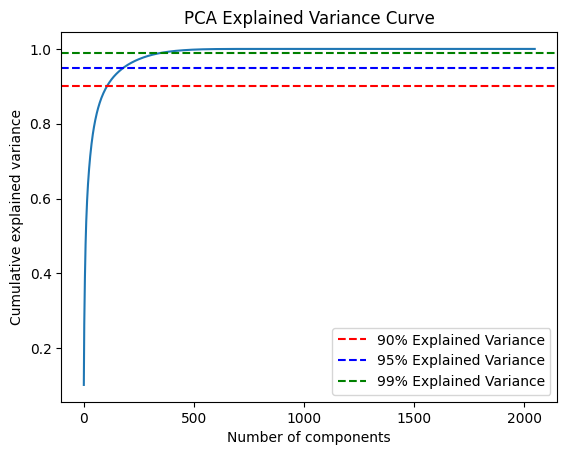

In [93]:
pca_full = PCA()
pca_full.fit(X_train_norm)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure()
plt.plot(cumulative)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance Curve")
plt.axhline(0.90, color='red', linestyle='--', label='90% Explained Variance')
plt.axhline(0.95, color='blue', linestyle='--', label='95% Explained Variance')
plt.axhline(0.99, color='green', linestyle='--', label='99% Explained Variance')
plt.legend()
plt.show()

In [94]:
def pick_components(cumvar, target=0.95):
    return np.argmax(cumvar >= target) + 1

n_95 = pick_components(cumulative, 0.95)
n_90 = pick_components(cumulative, 0.90)

print(n_95, n_90)

182 106


In [95]:
pca = PCA(n_components=n_95, random_state=42)

X_train_pca = pca.fit_transform(X_train_norm)
X_test_pca = pca.transform(X_test_norm)

In [ ]:
# !pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 9.5 MB/s eta 0:00:00a 0:00:01


## LightGBM without PCA_95

In [96]:
lgbm_raw = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

lgbm_raw.fit(X_train_norm, y_train)

y_pred_lgbm_raw = lgbm_raw.predict(X_test_norm)

print("LightGBM without PCA")
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm_raw))
print("Macro F1:", f1_score(y_test, y_pred_lgbm_raw, average="macro"))
# print(classification_report(y_test, y_pred_lgbm_raw))

LightGBM without PCA
Accuracy: 0.61
Macro F1: 0.6096600953542116


/home/jakub-karczewski/Dokumenty/data_exploration_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## LightGBM with PCA

In [100]:
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# lgbm_pca = LGBMClassifier(
#     n_estimators=300,
#     learning_rate=0.05,
#     random_state=42,
#     verbose=-1
# )

lgbm_pca = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.03,
    num_leaves=15,
    max_depth=4,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1
)

lgbm_pca.fit(X_train_pca, y_train)

y_pred_lgbm_pca_test = lgbm_pca.predict(X_test_pca)
y_pred_lgbm_pca_train = lgbm_pca.predict(X_train_pca)


print("LightGBM + PCA")
print("Train Accuracy:", accuracy_score(y_train, y_pred_lgbm_pca_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_lgbm_pca_test))
print("Macro F1:", f1_score(y_test, y_pred_lgbm_pca_test, average="macro"))
# print(classification_report(y_test, y_pred_lgbm_pca))

LightGBM + PCA
Train Accuracy: 0.8173287456990929
Test Accuracy: 0.59875
Macro F1: 0.5953575779976159


/home/jakub-karczewski/Dokumenty/data_exploration_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/jakub-karczewski/Dokumenty/data_exploration_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Logistic Regression with PCA

In [102]:
logreg = LogisticRegression(
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

logreg.fit(X_train_pca, y_train)

y_pred_lr = logreg.predict(X_test_pca)
y_pred_lr_test = logreg.predict(X_test_pca)
y_pred_lr_train = logreg.predict(X_train_pca)

print("Logistic Regression")
print("Train Accuracy:", accuracy_score(y_train, y_pred_lr_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_lr_test))
print("Macro F1:", f1_score(y_test, y_pred_lr_test, average="macro"))
# print(classification_report(y_test, y_pred_lr))

/home/jakub-karczewski/Dokumenty/data_exploration_project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression
Train Accuracy: 0.6718798873944323
Test Accuracy: 0.61125
Macro F1: 0.6103552027182333


In [103]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [6, 7, 8, 10, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train_pca, y_train)


print("Best parameters:")
print(grid_rf.best_params_)

best_rf = grid_rf.best_estimator_
y_pred_train_rf = best_rf.predict(X_train_pca)
y_pred_test_rf = best_rf.predict(X_test_pca)

train_acc = accuracy_score(y_train, y_pred_train_rf)
test_acc = accuracy_score(y_test, y_pred_test_rf)

print("Best CV Macro F1:")
print(grid_rf.best_score_)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Fitting 3 folds for each of 180 candidates, totalling 540 fits
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   2.1s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   2.3s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, min_samples_leaf=2, n_estimators=100; total time=   2.4s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   2.4s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, min_samples_leaf=2, n_estimators=100; total time=   2.5s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, min_samples_leaf=2, n_estimators=100; total time=   2.6s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, min_samples_leaf=4, n_estimators=100; total time=   3.2s
[CV] END bootstrap=True, max_depth=6, max_features=sqrt, min_samples_leaf=1, n_estimators=150; total time=   3.4s
[CV] END bootstrap=True, 

/home/jakub-karczewski/Dokumenty/data_exploration_project/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/jakub-karczewski/Dokumenty/data_exploration_project/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/jakub-karczewski/Dokumenty/data_exploration_project/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the curre

[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   5.8s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=4, n_estimators=200; total time=   7.3s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   6.8s
[CV] END bootstrap=True, max_depth=10, max_features=log2, min_samples_leaf=4, n_estimators=200; total time=   7.6s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimators=100; total time=   6.2s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=150; total time=   8.4s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, n_estimators=100; total time=   6.6s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=150; total time=   9.0s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samp

/home/jakub-karczewski/Dokumenty/data_exploration_project/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/jakub-karczewski/Dokumenty/data_exploration_project/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/jakub-karczewski/Dokumenty/data_exploration_project/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the curre

[CV] END bootstrap=False, max_depth=7, max_features=sqrt, min_samples_leaf=1, n_estimators=100; total time=   7.5s
[CV] END bootstrap=False, max_depth=6, max_features=log2, min_samples_leaf=4, n_estimators=200; total time=   8.3s
[CV] END bootstrap=False, max_depth=7, max_features=sqrt, min_samples_leaf=2, n_estimators=100; total time=   6.5s
[CV] END bootstrap=False, max_depth=7, max_features=sqrt, min_samples_leaf=2, n_estimators=100; total time=   7.5s
[CV] END bootstrap=False, max_depth=7, max_features=sqrt, min_samples_leaf=2, n_estimators=100; total time=   9.1s
[CV] END bootstrap=False, max_depth=7, max_features=sqrt, min_samples_leaf=1, n_estimators=150; total time=  11.7s
[CV] END bootstrap=False, max_depth=7, max_features=sqrt, min_samples_leaf=1, n_estimators=150; total time=  12.0s
[CV] END bootstrap=False, max_depth=7, max_features=log2, min_samples_leaf=1, n_estimators=100; total time=   4.5s
[CV] END bootstrap=False, max_depth=7, max_features=log2, min_samples_leaf=1, n_